# $\text{Taller: Autoencoders Variacionales (VAE)}$

## $\text{Generación de Rostros}$

---
## $\text{Tabla de Contenido}$

1. $\text{Importar Librerías}$
2. $\text{Introducción a los Autoencoder Variacional}$
3. $\text{Carga y Preparación de Datos (Dataset LFW)}$
4. $\text{Construcción de un Autoencoder Convolucional (AE) Base}$
5. $\text{Entrenamiento del AE y Visualización de Reconstrucciones}$
6. $\text{Construcción del Autoencoder Variacional (VAE)}$
   
7. $\text{Entrenamiento del VAE y Generación de Nuevos Rostros}$

8. $\text{Explorando el Espacio Latente: Aritmética de Rostros (Añadir Sonrisas)}$

## 1. $\text{Importar Librerías}$

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import pandas as pd

## 2. $\text{Introducción a los Autoencoder Variacional}$

### ¿Qué es un Autoencoder Variacional (VAE)?

| **Componente Clave**                | **Función en el VAE**                                                                 | **Analogía del "Artista Organizado"**                                                                 |
|------------------------------------|----------------------------------------------------------------------------------------|--------------------------------------------------------------------------------------------------------|
| **Encoder Probabilístico**         | En lugar de un punto, mapea la entrada a una distribución de probabilidad (media $\mu$ y varianza $\sigma^2$). | El artista no escribe notas exactas, sino que dibuja una "nube de posibilidades" para la esencia de la foto. |
| **Espacio Latente ($z$)**          | Un vector muestreado de la distribución ($z = \mu + \varepsilon \cdot \sigma$). Introduce aleatoriedad controlada. | Se toma una "nota" al azar de dentro de esa nube de posibilidades.                                   |
| **Decoder**                        | Reconstruye la imagen original a partir del vector latente $z$, igual que en un AE estándar.         | El artista redibuja la foto usando solo la nota muestreada.                                          |
| **Pérdida de Reconstrucción**      | Mide qué tan parecida es la imagen reconstruida a la original (e.g., Entropía Cruzada Binaria).        | El dibujo final debe parecerse al original. ¡El artista debe ser un buen copista!                    |
| **Pérdida de Regularización (KL)** | Fuerza a que las distribuciones aprendidas en el espacio latente se parezcan a una normal estándar $\mathcal{N}(0, 1)$. | Todas las "nubes de posibilidades" deben estar bien organizadas y cerca del centro del "tablero de notas", no dispersas. |

---

### La Magia del VAE

Al forzar este espacio latente a ser **organizado y continuo**, podemos tomar un punto aleatorio $z$ y el Decoder sabrá cómo **interpretarlo** para generar una imagen completamente **nueva y realista**.


## 3. $\text{Carga y Preparación de Datos (Dataset LFW)}$


### 3.1 Cargar y Preparar el Dataset LFW con TFDS

In [ ]:
# --- Configuración Inicial ---
np.random.seed(47)
tf.random.set_seed(47)

IMG_SIZE = 64 # Redimensionaremos las imágenes a 64x64 para un entrenamiento más rápido
BATCH_SIZE = 128
LATENT_DIM = 100 # Dimensión del espacio latente (nuestro vector 'z')

dataset_tfds, info = tfds.load('lfw', split='train', with_info=True, as_supervised=False)

### 3.2 Preprocesamiento de las Imágenes

In [ ]:
def preprocess(features):
    # Redimensionar la imagen al tamaño deseado
    image = tf.image.resize(features['image'], (IMG_SIZE, IMG_SIZE))
    # Normalizar los píxeles al rango [0, 1] y convertir a float32
    image = tf.cast(image, tf.float32) / 255.0
    return image, image # Para un autoencoder, la entrada y la salida (objetivo) son la misma imagen

# Aplicar el preprocesamiento y preparar el pipeline de datos
# shuffle: Baraja los datos para un mejor entrenamiento
# batch: Agrupa los datos en lotes
# prefetch: Carga previamente el siguiente lote en la GPU/CPU mientras el actual se procesa
train_dataset = dataset_tfds.map(preprocess).shuffle(buffer_size=1024).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("\nDataset preparado y listo para el entrenamiento.")


Dataset preparado y listo para el entrenamiento.


### 3.3 Visualizar algunos ejemplos preprocesados

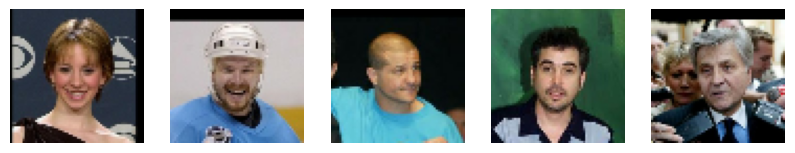

In [ ]:
plt.figure(figsize=(10, 4))
# Tomamos un lote del dataset preparado
for images, _ in train_dataset.take(1):
    for i in range(5):
        ax = plt.subplot(1, 5, i + 1)
        plt.imshow(images[i])
        plt.axis("off")
plt.show()

## 4. $\text{Construcción de un Autoencoder Convolucional (AE) Base}$


### 4.1. Definición de la Arquitectura del Encode

- El Encoder toma una imagen y la comprime en un vector latente.
- Se define la entrada que espera el Encoder: una imagen `64x64` con `3` canales de color.

In [ ]:
# borrar caché de tensor keras
keras.backend.clear_session()

# 1. Definimos la entrada que espera el Encoder: una imagen 64x64 con 3 canales.
encoder_inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name="entrada_encoder")

# 2. Apilamos capas convolucionales para extraer características y reducir el tamaño.
# strides=2 en Conv2D es una forma eficiente de reducir a la mitad el tamaño (alto y ancho).
x = layers.Conv2D(64, kernel_size=3, activation="relu", strides=2, padding="same")(encoder_inputs)
x = layers.Conv2D(128, kernel_size=3, activation="relu", strides=2, padding="same")(x)

# 3. Aplanamos el resultado para convertirlo en un vector largo.
x = layers.Flatten()(x)

# 4. Una capa densa para una compresión final en el espacio latente.
latent_space = layers.Dense(LATENT_DIM, name="espacio_latente")(x)

# 5. Creamos el modelo del Encoder.
encoder = keras.Model(encoder_inputs, latent_space, name="encoder")
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ entrada_encoder (InputLayer)    │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ espacio_latente (Dense)         │ (None, 100)            │     3,276,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,352,548 (12.79 MB)

 Trainable params: 3,352,548 (12.79 MB)

 Non-trainable params: 0 (0.00 B)

### 4.2. Definición de la Arquitectura del Decoder
El Decoder toma el vector latente y trata de reconstruir la imagen original

In [ ]:
# 1. Definimos la entrada que espera el Decoder: un vector del tamaño del espacio latente.
latent_inputs = keras.Input(shape=(LATENT_DIM,), name="entrada_decoder")

# 2. Expandimos el vector latente para que tenga suficientes neuronas para ser remodelado.
# El tamaño debe coincidir con el de la salida de la última capa convolucional antes de Flatten().
# En nuestro encoder, la última capa Conv2D produce un mapa de (16, 16, 64).
# Por lo tanto, necesitamos 16 * 16 * 64 neuronas.
x = layers.Dense(16 * 16 * 128, activation="relu")(latent_inputs)

# 3. Remodelamos el vector para que vuelva a tener la forma de un mapa de características 3D.
x = layers.Reshape((16, 16, 128))(x)

# 4. Usamos capas Conv2DTranspose ('deconvoluciones') para aumentar el tamaño de la imagen.
# Hacen lo contrario a Conv2D con strides=2.
x = layers.Conv2DTranspose(128, kernel_size=3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(64, kernel_size=3, activation="relu", strides=2, padding="same")(x)

# 5. La capa final reconstruye la imagen a su tamaño original con 3 canales.
# Usamos activación 'sigmoid' para asegurar que los valores de los píxeles estén entre 0 y 1.
decoder_outputs = layers.Conv2DTranspose(3, kernel_size=3, activation="sigmoid", padding="same")(x)

# 6. Creamos el modelo del Decoder.
decoder = keras.Model(latent_inputs, decoder_outputs, name="decoder")
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ entrada_decoder (InputLayer)    │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32768)          │     3,309,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 32, 32, 128)    │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 64, 64, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 64, 64, 3)      │         1,731 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,532,675 (13.48 MB)

 Trainable params: 3,532,675 (13.48 MB)

 Non-trainable params: 0 (0.00 B)

### 4.3. Construcción y Compilación del Autoencoder Completo

In [ ]:
# Conectamos el encoder y el decoder.
# La salida del autoencoder es lo que el decoder produce a partir de la salida del encoder.
autoencoder_output = decoder(encoder(encoder_inputs))

# El modelo completo va desde la entrada original hasta la salida reconstruida.
autoencoder = keras.Model(encoder_inputs, autoencoder_output, name="autoencoder")

# Compilamos el modelo.
# 'binary_crossentropy' es una excelente función de pérdida para medir el error de
# reconstrucción de imágenes píxel a píxel cuando los valores están normalizados entre 0 y 1.
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ entrada_encoder (InputLayer)    │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 100)            │     3,352,548 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 64, 64, 3)      │     3,532,675 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,885,223 (26.27 MB)

 Trainable params: 6,885,223 (26.27 MB)

 Non-trainable params: 0 (0.00 B)

## 5. $\text{Entrenamiento del AE y Visualización de Reconstrucciones}$


### 5.1. Construcción del Encoder VAE

Epoch 1/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 20s 104ms/step - loss: 0.6450
Epoch 2/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - loss: 0.5504
Epoch 3/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 10s 56ms/step - loss: 0.5280
Epoch 4/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - loss: 0.5169
Epoch 5/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 10s 55ms/step - loss: 0.5105
Epoch 6/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step - loss: 0.5069
Epoch 7/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 10s 57ms/step - loss: 0.5054
Epoch 8/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 10s 56ms/step - loss: 0.5034
Epoch 9/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - loss: 0.5022
Epoch 10/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 10s 57ms/step - loss: 0.5015
Epoch 11/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - loss: 0.5009
Epoch 12/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - loss: 0.4999
Epoch 13/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - loss: 0.4992
Epoch 14/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 10s 56ms/step - loss: 0.4985
Epoch 15/50
104/104 ━━━━━━━━━━━━━━━

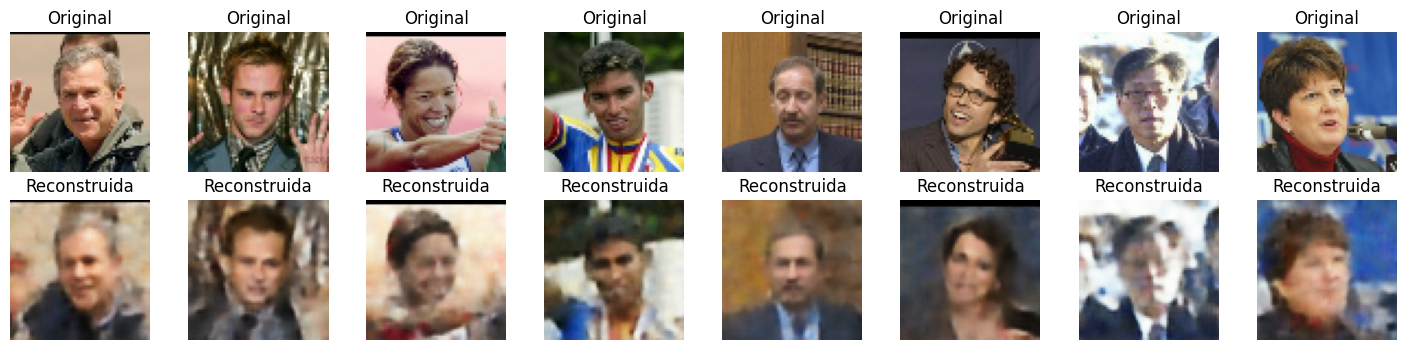

In [ ]:
# Entrenamos el modelo por 20 épocas. En un autoencoder, las entradas (imágenes)
# son también las salidas deseadas (objetivos). Keras lo maneja automáticamente.
history_ae = autoencoder.fit(
    train_dataset,
    epochs=50, # Menos épocas, ya que este es solo un modelo base
    verbose=1
)

def plot_reconstrucciones(model, dataset, n_imagenes=8):
    """Función para visualizar imágenes originales vs. reconstruidas."""
    plt.figure(figsize=(18, 4))
    print("Fila superior: Imágenes Originales. Fila inferior: Reconstruidas por el AE.")

    # Tomamos un lote del dataset para visualizar
    for imagenes, _ in dataset.take(1):
        # Usamos el modelo para predecir (reconstruir) el lote de imágenes
        imagenes_reconstruidas = model.predict(imagenes, verbose=0)
        for i in range(n_imagenes):
            # Graficar imagen original
            ax = plt.subplot(2, n_imagenes, i + 1)
            plt.imshow(imagenes[i])
            plt.title("Original")
            plt.axis("off")

            # Graficar imagen reconstruida
            ax = plt.subplot(2, n_imagenes, i + 1 + n_imagenes)
            plt.imshow(imagenes_reconstruidas[i])
            plt.title("Reconstruida")
            plt.axis("off")
    plt.show()

print("\nComparación de imágenes originales vs. reconstruidas por el AE:")
plot_reconstrucciones(autoencoder, train_dataset)

### 5.2. Conexión de las Piezas y Definición de la Pérdida KL

## 6. $\text{Construcción del Autoencoder Variacional (VAE)}$
   

In [ ]:
# --- 6. Construcción de un Autoencoder Variacional (VAE) Más Potente ---
print("\n--- 6. Construyendo una Arquitectura VAE Mejorada ---")

# Hiperparámetros (podemos redefinir o ajustar aquí)
LATENT_DIM = 256 # Aumentamos la dimensión del espacio latente para capturar más detalles
KL_WEIGHT = 0.00005 # Factor de ponderación para la pérdida KL. Un valor pequeño prioriza la reconstrucción.

# --- 6.1. Piezas del VAE Mejorado: Encoder y Decoder ---

# ENCODER MEJORADO
# Más capas, sin el cuello de botella de Dense(16)
encoder_inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(encoder_inputs)
x = layers.Conv2D(128, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2D(256, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Flatten()(x)
# Ahora, directamente al espacio latente
z_mean = layers.Dense(LATENT_DIM, name="z_mean")(x)
z_log_var = layers.Dense(LATENT_DIM, name="z_log_var")(x)
encoder = keras.Model(encoder_inputs, [z_mean, z_log_var], name="encoder_mejorado")
print("\n--- Resumen del Encoder Mejorado ---")
encoder.summary()

# DECODER MEJORADO
# Arquitectura inversa a la del encoder mejorado.
latent_inputs = keras.Input(shape=(LATENT_DIM,))
# La forma a la que debemos remodelar es la de la salida de la última capa Conv2D del encoder.
# Si la entrada es 64x64, después de 3 capas con stride=2, el tamaño es 64 -> 32 -> 16 -> 8.
# La forma es (8, 8, 128)
x = layers.Dense(8 * 8 * 128, activation="relu")(latent_inputs)
x = layers.Reshape((8, 8, 128))(x)
x = layers.Conv2DTranspose(128, 3, activation="relu", strides=2, padding="same")(x) # 8x8 -> 16x16
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)  # 16x16 -> 32x32
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)  # 32x32 -> 64x64
decoder_outputs = layers.Conv2DTranspose(3, 3, activation="sigmoid", padding="same")(x)
decoder = keras.Model(latent_inputs, decoder_outputs, name="decoder_mejorado")
print("\n--- Resumen del Decoder Mejorado ---")
decoder.summary()

# --- 6.2. Definición del Modelo VAE Personalizado (usando la misma clase de antes) ---
# La clase VAE que definimos antes es genérica y funcionará con nuestro nuevo encoder y decoder.
class VAE(keras.Model):
    def __init__(self, encoder, decoder, kl_weight, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.kl_weight = kl_weight # Guardamos el peso para la pérdida KL
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.reconstruction_loss_tracker, self.kl_loss_tracker]

    def train_step(self, data):
        if isinstance(data, tuple): x = data[0]
        else: x = data

        with tf.GradientTape() as tape:
            z_mean, z_log_var = self.encoder(x)
            # Muestreo de z
            batch = tf.shape(z_mean)[0]
            dim = tf.shape(z_mean)[1]
            epsilon = tf.random.normal(shape=(batch, dim))
            z = z_mean + tf.exp(0.5 * z_log_var) * epsilon
            # Reconstrucción
            reconstruction = self.decoder(z)
            # Cálculo de pérdidas
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(keras.losses.binary_crossentropy(x, reconstruction), axis=(1, 2))
            )
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
            )
            # Aplicamos el peso a la pérdida KL antes de sumarlas
            total_loss = reconstruction_loss + self.kl_weight * kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {m.name: m.result() for m in self.metrics}

# --- 6.3. Instanciar y Compilar el Modelo VAE Mejorado ---
vae_mejorado = VAE(encoder=encoder, decoder=decoder, kl_weight=KL_WEIGHT)
vae_mejorado.compile(optimizer=keras.optimizers.Adam())


--- 6. Construyendo una Arquitectura VAE Mejorada ---

--- Resumen del Encoder Mejorado ---


Model: "encoder_mejorado"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 16, 16,    │     73,856 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 8, 8, 256) │    295,168 │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 16384)     │          0 │ conv2d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 256)       │  4,194,560 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 256)       │  4,194,560 │ flatten_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 8,759,936 (33.42 MB)

 Trainable params: 8,759,936 (33.42 MB)

...

Model: "decoder_mejorado"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8192)           │     2,105,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 16, 16, 128)    │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 32, 32, 64)     │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_5              │ (None, 64, 64, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_6              │ (None, 64, 64, 3)      │           867 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,346,051 (8.95 MB)

 Trainable params: 2,346,051 (8.95 MB)

 Non-trainable params: 0 (0.00 B)

## 7. $\text{Entrenamiento del VAE y Generación de Nuevos Rostros}$



--- Entrenando el Autoencoder Variacional (VAE) ---
Epoch 1/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 14s 73ms/step - kl_loss: 359.3088 - reconstruction_loss: 2680.0789 - total_loss: 2680.0964
Epoch 2/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - kl_loss: 1487.6608 - reconstruction_loss: 2292.2581 - total_loss: 2292.3330
Epoch 3/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - kl_loss: 1521.0934 - reconstruction_loss: 2200.4160 - total_loss: 2200.4922
Epoch 4/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - kl_loss: 1486.5005 - reconstruction_loss: 2160.6509 - total_loss: 2160.7256
Epoch 5/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - kl_loss: 1466.8628 - reconstruction_loss: 2123.4998 - total_loss: 2123.5735
Epoch 6/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - kl_loss: 1463.1122 - reconstruction_loss: 2099.4509 - total_loss: 2099.5242
Epoch 7/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - kl_loss: 1462.9955 - reconstruction_loss: 2082.3472 - total_loss: 2082.4207
Epoch 8/100
104/104 ━━━

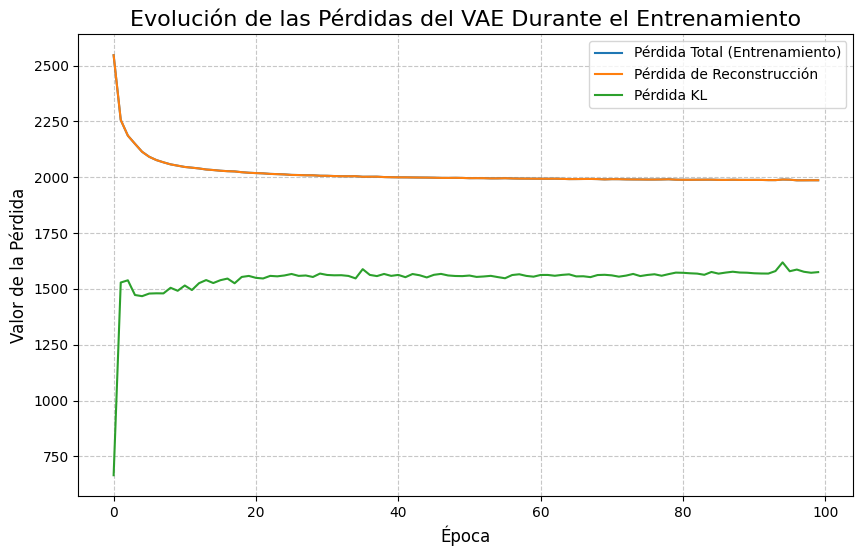


Generando nuevos rostros usando el Decoder del VAE:


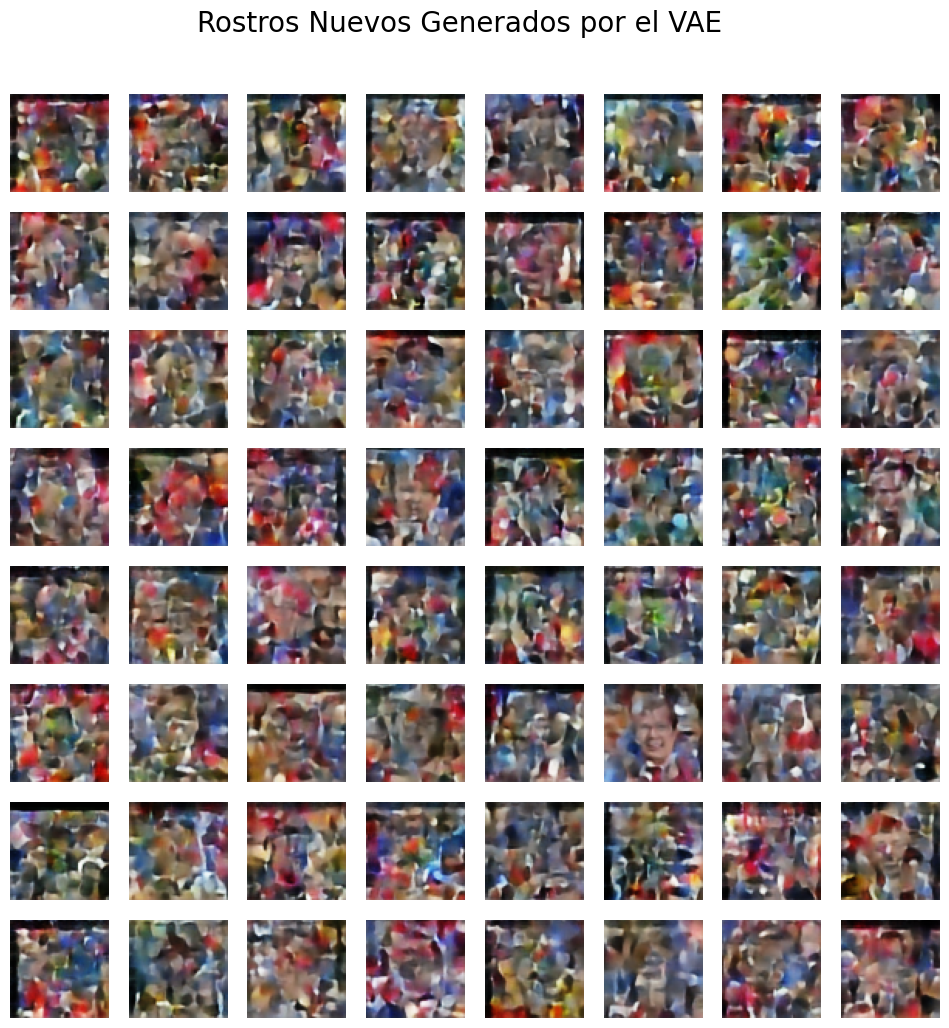

In [ ]:
# --- 7. Entrenamiento del VAE y Generación de Nuevos Rostros ---
print("\n--- Entrenando el Autoencoder Variacional (VAE) ---")

history_vae_mejorado = vae_mejorado.fit(
    train_dataset,
    epochs=100, # Aumentamos las épocas
    verbose=1
)

# --- Visualización de la Pérdida ---
plt.figure(figsize=(10, 6))
plt.plot(history_vae_mejorado.history['total_loss'], label='Pérdida Total (Entrenamiento)')
plt.plot(history_vae_mejorado.history['reconstruction_loss'], label='Pérdida de Reconstrucción')
plt.plot(history_vae_mejorado.history['kl_loss'], label='Pérdida KL')
plt.title('Evolución de las Pérdidas del VAE Durante el Entrenamiento', fontsize=16)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Valor de la Pérdida', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# --- Generación de Nuevos Rostros ---
def plot_nuevos_rostros(decoder_model, n=8, figsize=12):
    """Genera y grafica rostros a partir de vectores latentes aleatorios."""
    print("\nGenerando nuevos rostros usando el Decoder del VAE:")
    plt.figure(figsize=(figsize, figsize));
    # Muestreamos puntos aleatorios de una distribución normal estándar
    vectores_latentes_aleatorios = tf.random.normal(shape=(n * n, LATENT_DIM))
    # Usamos el decoder para generar las imágenes
    imagenes_generadas = decoder_model.predict(vectores_latentes_aleatorios, verbose=0)
    for i in range(n * n):
        ax = plt.subplot(n, n, i + 1); plt.imshow(imagenes_generadas[i]); plt.axis("off")
    plt.suptitle("Rostros Nuevos Generados por el VAE", fontsize=20, y=0.95); plt.show()


Generando nuevos rostros usando el Decoder del VAE:


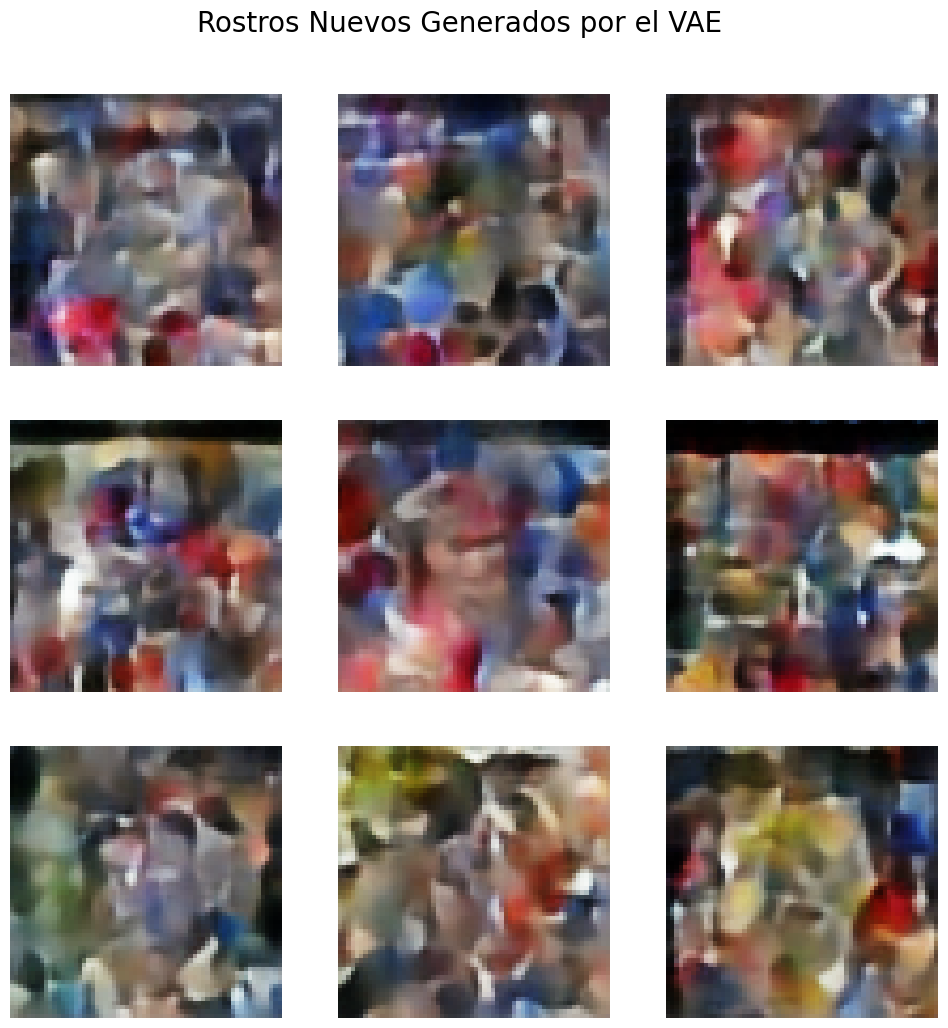

In [ ]:
# Para generar, usamos el modelo 'decoder' que fue entrenado como parte del VAE.
plot_nuevos_rostros(vae_mejorado.decoder, n=3)

## 8. $\text{Explorando el Espacio Latente: Transición entre Rostros}$


--- Interpolando entre dos rostros en el espacio latente ---
Fila superior: Imágenes originales. Fila inferior: Transición generada.


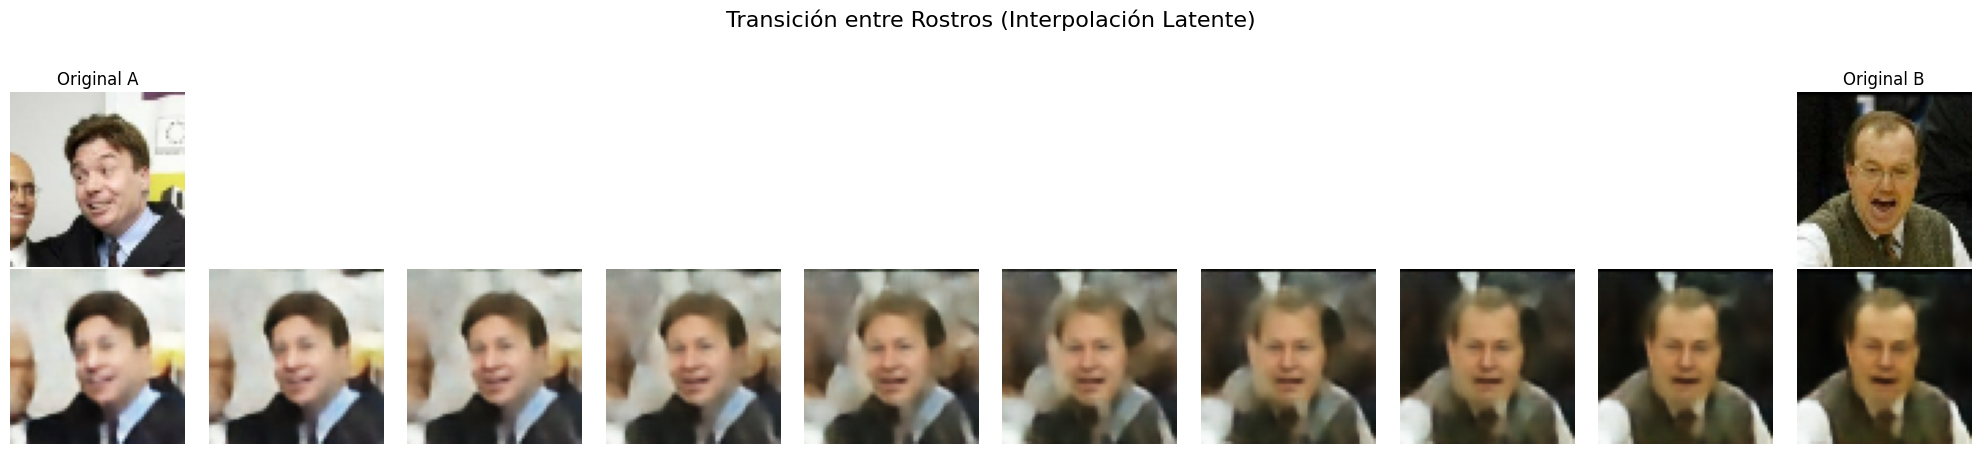

In [ ]:
# --- 8. Explorando el Espacio Latente con el Modelo Mejorado ---

# El encoder que usaremos es el que está dentro de nuestra instancia de VAE mejorado
encoder_interpolacion_mejorado = vae_mejorado.encoder
decoder_interpolacion_mejorado = vae_mejorado.decoder

def plot_interpolacion(encoder_model, decoder_model, dataset, n_pasos=10):
    """Muestra una transición suave entre dos rostros."""
    print("\n--- Interpolando entre dos rostros en el espacio latente ---")

    # Tomamos un lote de imágenes del dataset para trabajar con ellas.
    for imagenes, _ in dataset.take(1):
        # Seleccionamos dos imágenes del lote para interpolar entre ellas.
        # Guardamos la primera y la sexta imagen en variables separadas.
        imagen_original_A = imagenes[0:1]
        imagen_original_B = imagenes[5:6]

        # Obtenemos sus representaciones latentes (la media) usando nuestro encoder.
        # El encoder devuelve una lista [z_mean, z_log_var], nos quedamos solo con la primera parte.
        z_mean_A, _ = encoder_model.predict(imagen_original_A, verbose=0)
        z_mean_B, _ = encoder_model.predict(imagen_original_B, verbose=0)

        # Creamos una secuencia de puntos intermedios en línea recta entre z_mean_A y z_mean_B.
        pasos_alpha = np.linspace(0, 1, n_pasos)
        vectores_interpolados = [z_mean_A * (1 - alpha) + z_mean_B * alpha for alpha in pasos_alpha]
        vectores_interpolados = np.array(vectores_interpolados).reshape(n_pasos, LATENT_DIM)

        # Decodificamos los puntos intermedios para generar las imágenes de transición.
        imagenes_interpoladas = decoder_model.predict(vectores_interpolados, verbose=0)

        # --- Ahora, graficamos los resultados ---
        print("Fila superior: Imágenes originales. Fila inferior: Transición generada.")
        plt.figure(figsize=(n_pasos * 2, 4.5)) # Ajustar tamaño para que quepa todo

        for i in range(n_pasos):
            # --- Fila superior: Las originales en los extremos ---
            ax = plt.subplot(2, n_pasos, i + 1)
            # Solo dibujamos en el primer y último lugar de la fila superior.
            if i == 0:
                plt.imshow(imagen_original_A[0])
                plt.title("Original A")
            elif i == n_pasos - 1:
                plt.imshow(imagen_original_B[0])
                plt.title("Original B")
            plt.axis('off')

            # --- Fila inferior: La secuencia de imágenes interpoladas ---
            ax = plt.subplot(2, n_pasos, i + 1 + n_pasos)
            plt.imshow(imagenes_interpoladas[i])
            plt.axis('off')

    plt.suptitle("Transición entre Rostros (Interpolación Latente)", fontsize=16, y=1.0)
    plt.tight_layout(rect=[0, 0, 1, 0.95]) # Ajustar para que el suptitle no se solape
    plt.show()

plot_interpolacion(
    encoder_interpolacion_mejorado,
    decoder_interpolacion_mejorado,
    train_dataset
)